In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv(r"C:\Users\AB\Downloads\archive (6)\gold_price_forecasting_dataset.csv")

In [3]:
df.head()


,date,adj close,close,high,low,open,volume,ma_7,ma_30,ma_90,daily_return,volatility_7,volatility_30,rsi,macd,macd_signal,bb_upper,bb_lower
0,2021-06-11,1877.400024,1877.400024,1902.300049,1875.199951,1900.900024,349,1887.828561,1860.180005,1790.618891,-0.008869,0.009353,0.007538,54.722931,19.724030,24.933953,1918.242879,1853.797124
1,2021-06-14,1864.000000,1864.000000,1866.599976,1846.500000,1866.199951,41,1886.799997,1863.403337,1790.972225,-0.007138,0.006411,0.007711,49.391919,16.433420,23.233846,1913.119794,1861.530206
2,2021-06-15,1854.500000,1854.500000,1867.199951,1854.400024,1866.400024,78,1881.757132,1865.506669,1791.701114,-0.005097,0.004572,0.007474,45.972581,12.910196,21.169116,1914.969370,1858.380630
3,2021-06-16,1859.500000,1859.500000,1860.099976,1809.199951,1859.400024,117,1876.428554,1868.296667,1792.241113,0.002696,0.004348,0.007240,48.012515,10.401571,19.015607,1915.862799,1856.657196
4,2021-06-17,1773.800049,1773.800049,1823.300049,1769.599976,1811.800049,1135,1859.514282,1867.953337,1791.595558,-0.046088,0.016895,0.011288,28.293542,1.481124,15.508710,1938.202457,1823.567538


In [4]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1167 entries, 0 to 1166
Data columns (total 18 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   date           1167 non-null   object 
 1   adj close      1167 non-null   float64
 2   close          1167 non-null   float64
 3   high           1167 non-null   float64
 4   low            1167 non-null   float64
 5   open           1167 non-null   float64
 6   volume         1167 non-null   int64  
 7   ma_7           1167 non-null   float64
 8   ma_30          1167 non-null   float64
 9   ma_90          1167 non-null   float64
 10  daily_return   1167 non-null   float64
 11  volatility_7   1167 non-null   float64
 12  volatility_30  1167 non-null   float64
 13  rsi            1167 non-null   float64
 14  macd           1167 non-null   float64
 15  macd_signal    1167 non-null   float64
 16  bb_upper       1167 non-null   float64
 17  bb_lower       1167 non-null   float64
dtypes: float

In [5]:
df.describe()

,adj close,close,high,low,open,volume,ma_7,ma_30,ma_90,daily_return,volatility_7,volatility_30,rsi,macd,macd_signal,bb_upper,bb_lower
count,1167.000000,1167.000000,1167.000000,1167.000000,1167.000000,1167.000000,1167.000000,1167.000000,1167.000000,1167.000000,1167.000000,1167.000000,1167.000000,1167.000000,1167.000000,1167.000000,1167.000000
mean,2363.105823,2363.105823,2375.595715,2349.989545,2362.322109,4170.995716,2354.938862,2327.283295,2263.573357,0.000840,0.009373,0.009724,54.598187,16.332400,15.839374,2420.275644,2257.229746
std,749.127289,749.127289,757.244374,741.042344,749.389242,21394.527815,735.998718,697.354115,620.008940,0.010809,0.004356,0.002901,12.176024,31.412668,28.476902,758.759131,668.408638
min,1623.300049,1623.300049,1623.300049,1615.099976,1620.400024,0.000000,1643.671422,1659.240002,1705.499999,-0.113662,0.001791,0.004386,22.230260,-35.037415,-31.681349,1681.970545,1579.241564
25%,1827.299988,1827.299988,1831.600037,1816.800049,1825.250000,88.000000,1827.585711,1830.560004,1813.691667,-0.004360,0.006640,0.008116,46.452632,-4.904126,-4.022000,1881.291203,1775.139339
50%,1985.900024,1985.900024,1996.199951,1979.800049,1989.000000,297.000000,1986.785697,1978.813334,1948.046665,0.000945,0.008522,0.009115,53.983908,9.242215,9.448693,2038.438645,1932.450329
75%,2666.099976,2666.099976,2675.449951,2654.599976,2662.400024,867.500000,2654.771449,2659.524996,2588.156108,0.006842,0.011139,0.010711,62.790872,29.596166,28.529324,2728.408233,2582.183753
max,5318.399902,5318.399902,5586.200195,5301.600098,5415.700195,209783.000000,5070.914272,4620.783317,4252.532210,0.043643,0.051106,0.027369,87.227702,227.374043,170.076845,5310.168254,4263.597132


In [6]:
#HANDLE MISSING VALUES

for col in df.select_dtypes(include=['int64','float64']).columns:
    df[col] = df[col].fillna(df[col].median())

for col in df.select_dtypes(include=['object']).columns:
    df[col] = df[col].fillna(df[col].mode()[0])

In [7]:
# After removing outliers, we can check the shape of the dataset
print('The shape of the dataset after removing outliers:', df.shape)    
for col in df.select_dtypes(include=['int64','float64']).columns:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    df = df[(df[col] >= lower) & (df[col] <= upper)]

The shape of the dataset after removing outliers: (1167, 18)


In [8]:
#Encode Categorical Data
for col in df.select_dtypes(include=['object']).columns:
    df[col] = pd.factorize(df[col])[0]
    df = pd.get_dummies(df, drop_first=True)

In [ ]:
#Split Features & Target
for col in df.columns:
    print(f"'{col}'")

'date'
'adj close'
'close'
'high'
'low'
'open'
'volume'
'ma_7'
'ma_30'
'ma_90'
'daily_return'
'volatility_7'
'volatility_30'
'rsi'
'macd'
'macd_signal'
'bb_upper'
'bb_lower'


In [18]:
df.columns = df.columns.str.strip()

In [21]:

df.columns = df.columns.str.strip()


target = df.columns[-1]

X = df.drop(columns=[target])
y = df[target]

print("Target column:", target)

Target column: bb_lower


In [ ]:
#Train-Test Split

from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


In [25]:
from sklearn.linear_model import LogisticRegression
from sklearn.linear_model import LinearRegression

model = LinearRegression()
model.fit(X_train, y_train)

LinearRegression()

In [26]:
y_pred = model.predict(X_test)
print(y_pred)
comparison = pd.DataFrame({
    'Actual': y_test,
    'Predicted': y_pred
})

print(comparison.head())

[1964.93635479 1885.77765909 1741.99734097 1897.06164185 1964.12448894
 1727.37376843 1768.65154427 1636.39251005 1780.53994196 1770.57331451
 1982.40228372 1723.78638598 1971.56269067 1792.79398675 1891.80398244
 1683.1328198  1805.77863888 1725.21786189 1960.95133245 1800.17363693
 1795.1021666  1802.28419108 1853.1987653  2000.15702775 1807.52697711
 1720.52224757 1758.53657792 2043.32512447 1901.33720574 1747.38095415
 1878.10907868 1894.03539069 1758.82918832 1687.83346175 1744.87127654
 1757.11546127 1904.34486436 1908.74714869 1878.36886777 1996.10304595
 1696.3966341  1798.79799832 1846.55365291 1712.79116987 1893.70373151
 1810.30463238 1714.92411099 1784.3348588  1869.19342659 1788.60657138
 1724.89573675 1910.35418279 1736.7837483  1835.94141102 1811.53861622
 1678.47693787 2000.1753503  1938.71781924 1879.67148301 1916.9812013
 1731.96548865 1686.67726464 1846.32570872 1738.39354866 1730.24608474
 1685.96555183 1688.86462949 1899.2340747  1850.7947964  1719.68899901
 1771.2

In [29]:
#PREDICTING NEW VALUES
new_data = X.iloc[[0]]   # takes first row

prediction = model.predict(new_data)

print("Prediction:", prediction)

Prediction: [1849.80114541]


In [32]:
#Evaluate Model
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

y_pred = model.predict(X_test)

mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("MAE:", mae)
print("MSE:", mse)
print("R2 Score:", r2)

MAE: 6.039221524422969
MSE: 54.15008185343967
R2 Score: 0.9951041452939916


In [33]:
#RANDOM FOREST REGRESSOR
from sklearn.ensemble import RandomForestRegressor
rf_model = RandomForestRegressor(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)
rf_y_pred = rf_model.predict(X_test)
rf_mae = mean_absolute_error(y_test, rf_y_pred)
rf_mse = mean_squared_error(y_test, rf_y_pred)
rf_r2 = r2_score(y_test, rf_y_pred)
print("Random Forest MAE:", rf_mae)
print("Random Forest MSE:", rf_mse)
print("Random Forest R2 Score:", rf_r2)

Random Forest MAE: 8.38702629632285
Random Forest MSE: 181.1246531214971
Random Forest R2 Score: 0.9836240324112696


In [34]:
#IQR OUTLIER DETECTION
for col in df.select_dtypes(include=['float64', 'int64']).columns:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    df = df[(df[col] >= lower) & (df[col] <= upper)]

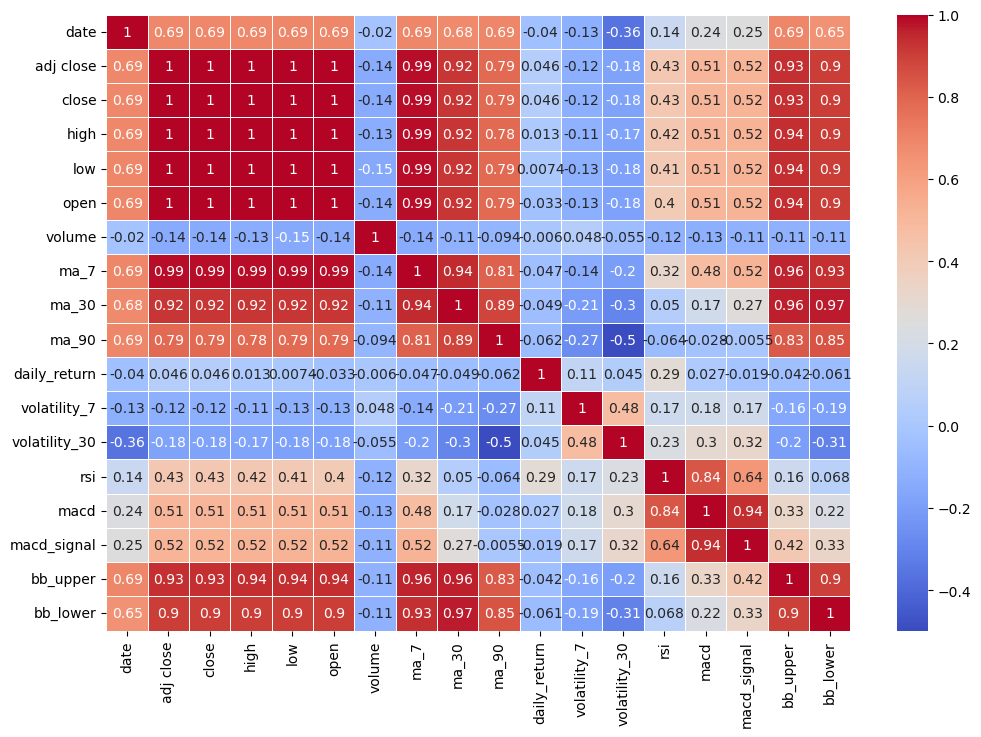

In [35]:
#  DATA Visualization
corr = df.select_dtypes(include=['int64','float64']).corr()

plt.figure(figsize=(12, 8))
sns.heatmap(corr, annot=True, cmap="coolwarm", linewidths=0.5)

plt.show()

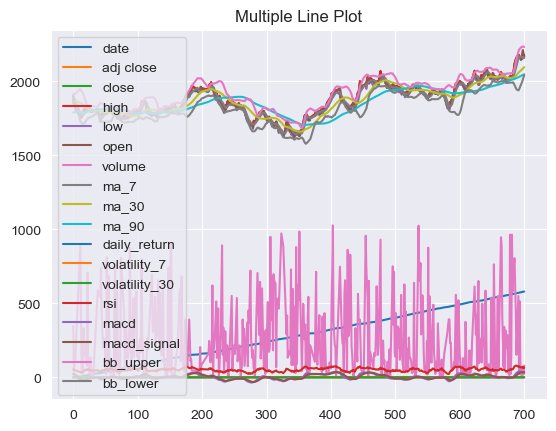

In [38]:
import matplotlib.pyplot as plt

numeric_df = df.select_dtypes(include=['int64', 'float64'])

numeric_df.plot()

plt.title("Multiple Line Plot")
plt.show()

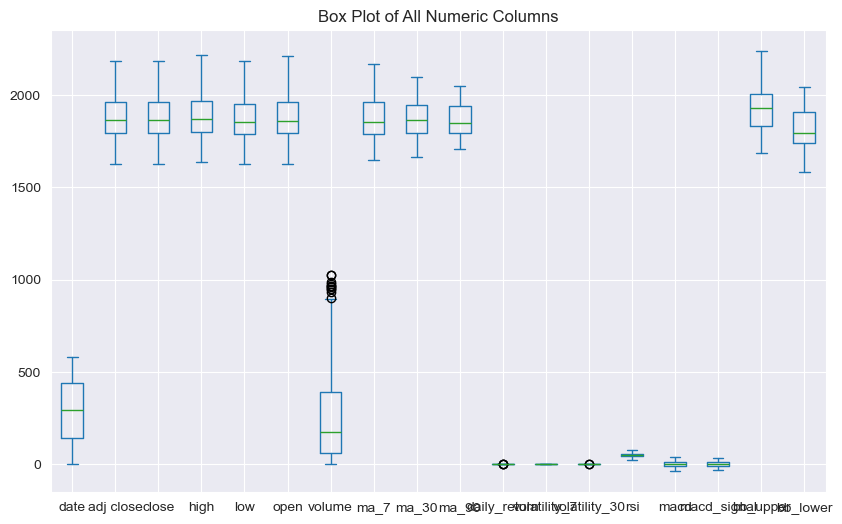

In [40]:
numeric_df = df.select_dtypes(include=['int64', 'float64'])

numeric_df.plot(kind='box', figsize=(10,6))

plt.title("Box Plot of All Numeric Columns")
plt.show()